### 1. Installation et Imports

In [120]:
%pip install kraken jiwer

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [121]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from tqdm import tqdm
from pathlib import Path
from jiwer import cer, wer
from kraken import blla, rpred
from kraken.lib import vgsl, models as kraken_models


### 2. Vérifier les modèles chargés

Dans le terminal:
```bash
# Lister les modèles disponibles
kraken list

# Télécharger un modèle adapté aux manuscrits français
kraken get 10.5281/zenodo.18715367
```

10.5281/zenodo.6669508
10.5281/zenodo.5617783

10.5281/zenodo.10788591

10.5281/zenodo.6657808
10.5281/zenodo.10886224
10.5281/zenodo.6657809 
10.5281/zenodo.10874058

10.5281/zenodo.13788177


Pour comprendre mieux comment intéragir avec les modèles de kraken reférez-vous à la documentation: [Model Management](https://kraken.re/main/user_guide/models.html)

Essai en télégargeant directement les modèles donnés sur Gallicorpora https://github.com/Gallicorpora/Segmentation-and-HTR-Models

In [122]:
# Dossier où Kraken stocke les modèles (dépend de votre installation)
# Pour D-FINE XL (segmentation) – DOI 10.5281/zenodo.18715367
SEG_MODEL_PATH = os.path.expanduser(
    "/home/barachiel/Documents/fluffy-computing-machine/Hetic/Cours/Computer Vision/Michel/CoursAnalysePhilologique/models/segmOntoCorpusSegmentation_fineTune_best.mlmodel"
)

# Pour le modèle HTR médiéval (reconnaissance) – DOI 10.5281/zenodo.5617783 ou autre
HTR_MODEL_PATH = os.path.expanduser(
    "/home/barachiel/Documents/fluffy-computing-machine/Hetic/Cours/Computer Vision/Michel/CoursAnalysePhilologique/models/Gallicorpora+_best.mlmodel"
)

# Vérification de l'existence des fichiers
for chemin, nom in [(SEG_MODEL_PATH, "Segmentation (D-FINE XL)"), (HTR_MODEL_PATH, "HTR (medieval)")]:
    if os.path.exists(chemin):
        taille = os.path.getsize(chemin) / 1e6
        print(f"{nom} : {chemin} ({taille:.1f} Mo)")
    else:
        raise FileNotFoundError(f"{nom} introuvable : {chemin}")


Segmentation (D-FINE XL) : /home/barachiel/Documents/fluffy-computing-machine/Hetic/Cours/Computer Vision/Michel/CoursAnalysePhilologique/models/segmOntoCorpusSegmentation_fineTune_best.mlmodel (5.1 Mo)
HTR (medieval) : /home/barachiel/Documents/fluffy-computing-machine/Hetic/Cours/Computer Vision/Michel/CoursAnalysePhilologique/models/Gallicorpora+_best.mlmodel (16.2 Mo)


In [123]:
# Paramètres
IMAGE_TEST = "../data/test/raw/voltaire_0.jpg" 
# IMAGE_TEST = "/home/barachiel/Documents/fluffy-computing-machine/Hetic/Cours/Computer Vision/Michel/CoursAnalysePhilologique/YOLO-GEN_Détection/Le_Roman_de_la_Rose_[...]Guillaume_de_btv1b6000369q_8.jpeg"
DOSSIER_XML = "sorties_xml"
MODE_LOT = False   # mode lot désactivé, on ne traite qu'une image


### 3. Chargement des modèles

In [124]:
def charger_modele_segmentation(chemin: str):
    """
    Charge un modèle de segmentation (BLLA ou D-FINE).
    """
    try:
        modele = vgsl.TorchVGSLModel.load_model(chemin)
        print(f"  Modèle segmentation chargé : {chemin}")
        print(f"  Type : {modele.model_type}")
        return modele
    except Exception as e:
        print(f"Erreur chargement segmentation : {e}")
        return None

def charger_modele_htr_kraken(chemin: str):
    """
    Charge un modèle de reconnaissance HTR Kraken.
    """
    try:
        modele = kraken_models.load_any(chemin)
        print(f"  Modèle HTR chargé : {getattr(modele, 'name', chemin)}")
        print(f"  Alphabet : {len(modele.codec)} caractères")
        return modele
    except Exception as e:
        print(f"Erreur chargement HTR : {e}")
        return None


In [125]:
# Chargement des modèles
modele_seg = charger_modele_segmentation(SEG_MODEL_PATH)
modele_htr = charger_modele_htr_kraken(HTR_MODEL_PATH)

if modele_seg is None or modele_htr is None:
    raise SystemExit("Erreur : un ou plusieurs modèles sont introuvables ou invalides.")

  Modèle segmentation chargé : /home/barachiel/Documents/fluffy-computing-machine/Hetic/Cours/Computer Vision/Michel/CoursAnalysePhilologique/models/segmOntoCorpusSegmentation_fineTune_best.mlmodel
  Type : segmentation
  Modèle HTR chargé : /home/barachiel/Documents/fluffy-computing-machine/Hetic/Cours/Computer Vision/Michel/CoursAnalysePhilologique/models/Gallicorpora+_best.mlmodel
  Alphabet : 160 caractères


### 4. Pré-traitement

In [126]:
def pretraiter_image(chemin_image, binariser=False, deskew=True, taille_max=4000):
    image = Image.open(chemin_image).convert("RGB")
    largeur, hauteur = image.size
    if max(largeur, hauteur) > taille_max:
        ratio = taille_max / max(largeur, hauteur)
        new_size = (int(largeur * ratio), int(hauteur * ratio))
        image = image.resize(new_size, Image.LANCZOS)
        print(f"  Redimensionné : {new_size[0]} × {new_size[1]} px")

    if deskew:
        image = _corriger_inclinaison(image)

    if binariser:
        gris = np.array(image.convert("L"))
        _, binaire = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        image = Image.fromarray(binaire).convert("RGB")

    return image

def _corriger_inclinaison(image_pil, angle_max=10.0):
    gris = np.array(image_pil.convert("L"))
    _, binaire = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = np.column_stack(np.where(binaire > 0))
    if len(coords) < 100:
        return image_pil
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = 90 + angle
    elif angle > 45:
        angle = angle - 90
    if abs(angle) > angle_max:
        print(f"  Angle {angle:.2f}° > {angle_max}°, ignoré")
        return image_pil
    if abs(angle) > 0.5:
        image_pil = image_pil.rotate(angle, expand=True, fillcolor=(255,255,255))
        print(f"  Inclinaison corrigée : {angle:.2f}°")
    return image_pil

  Redimensionné : 4000 × 2697 px


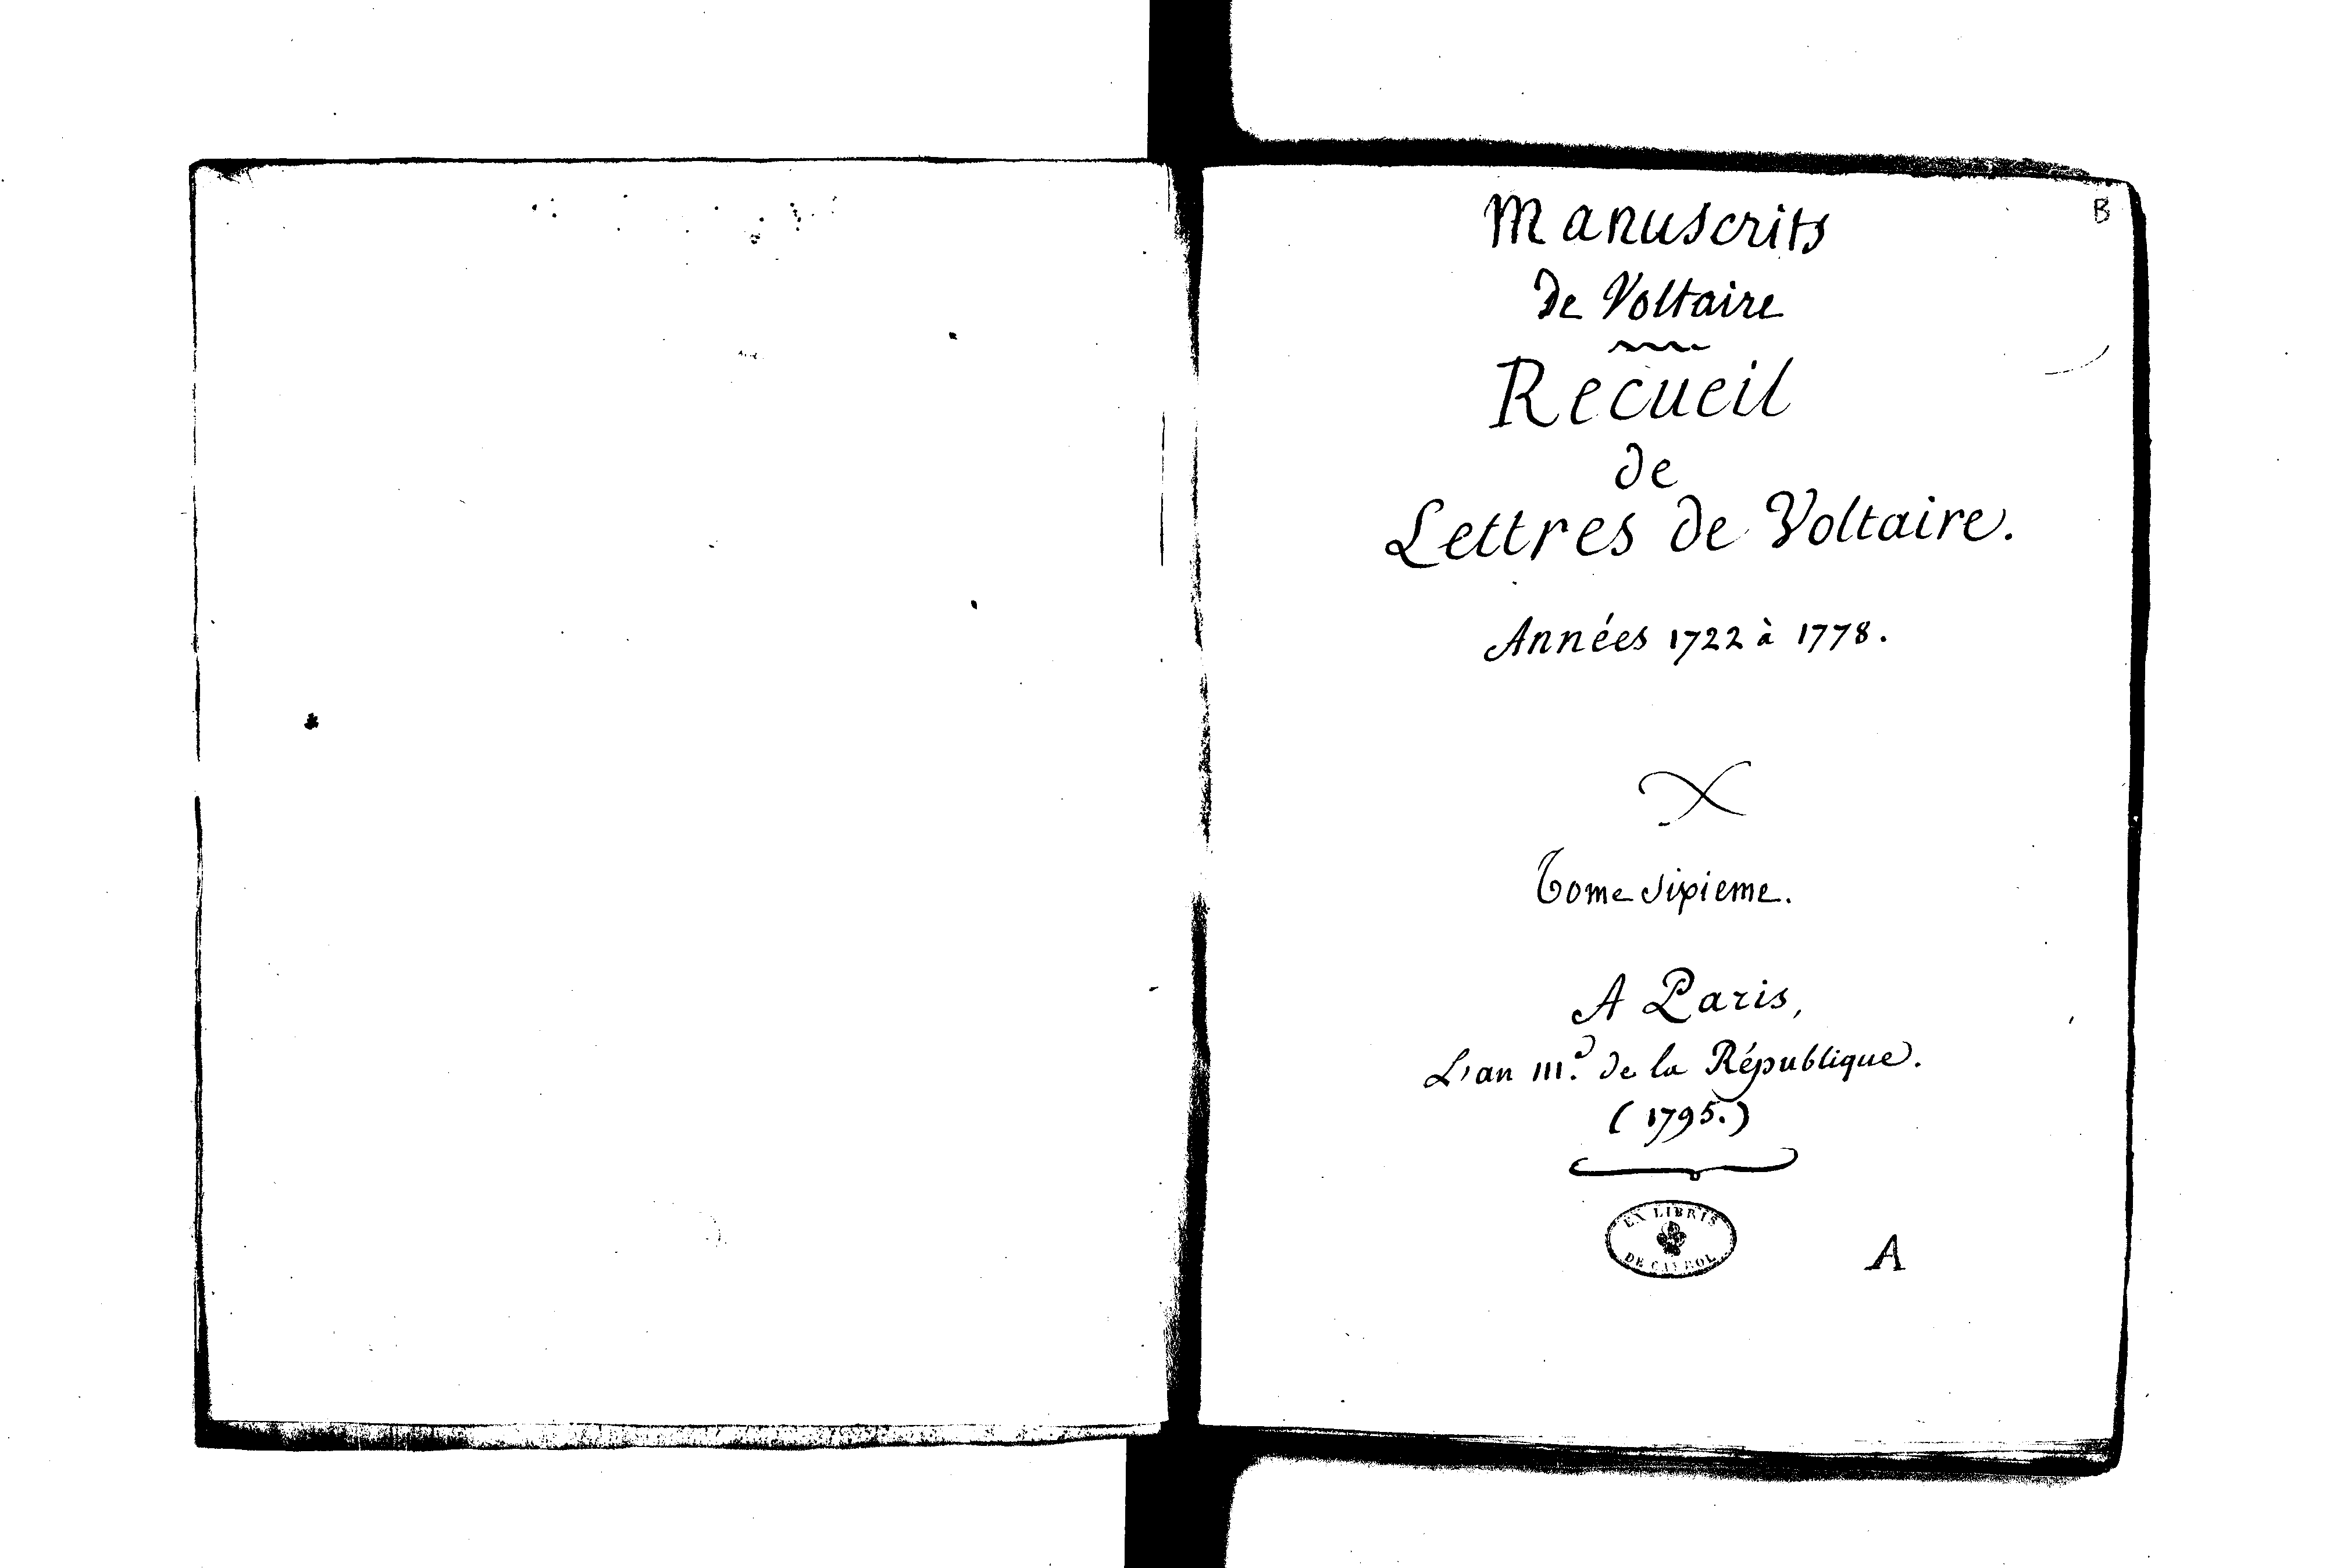

In [127]:
image = pretraiter_image(IMAGE_TEST, deskew=True, binariser=True)
image

### 5. Segmentation BLLA

In [128]:
def segmenter_page_blla(image_pil, modele_seg):
    """Segmente la page et retourne l'objet résultats."""
    if image_pil.mode not in ("RGB", "L"):
        image_pil = image_pil.convert("RGB")
    resultats = blla.segment(image_pil, model=modele_seg, text_direction="horizontal-lr")
    print(f"  Lignes détectées : {len(resultats.lines)}")
    print(f"  Types de régions : {list(resultats.regions.keys())}")
    return resultats

In [129]:
def visualiser_segmentation(
    image_pil,
    resultats_blla,
    n_lignes_max=None,
    figsize=(14, 18),
    titre="Segmentation BLLA"
):
    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(image_pil)
    ax.axis("off")
    ax.set_title(titre, fontsize=13)

    lignes = resultats_blla.lines

    if n_lignes_max:
        lignes = lignes[:n_lignes_max]

    for rang, ligne in tqdm(enumerate(lignes)):

        # ── Polygone ─────────────────────────────────────────────
        if ligne.boundary and len(ligne.boundary) >= 3:

            try:
                poly_pts = np.array(ligne.boundary)

                polygon = plt.Polygon(
                    poly_pts,
                    closed=True,
                    fill=False,
                    edgecolor="blue",
                    linewidth=1.5,
                    alpha=0.8
                )

                ax.add_patch(polygon)

            except Exception as e:
                print(f"Polygone invalide ligne {rang}: {e}")

        # ── Baseline ─────────────────────────────────────────────
        if ligne.baseline and len(ligne.baseline) >= 2:

            bx, by = zip(*ligne.baseline)

            ax.plot(
                bx,
                by,
                color="red",
                linewidth=1.0,
                alpha=0.7
            )

            ax.text(
                bx[0] - 5,
                by[0],
                str(rang + 1),
                fontsize=5,
                color="white",
                bbox=dict(
                    boxstyle="round,pad=0.1",
                    fc="steelblue",
                    alpha=0.7
                ),
                ha="right",
                va="center"
            )

    # ── Légende ─────────────────────────────────────────────────
    legend_elements = [
        plt.Line2D(
            [0], [0],
            color="cyan",
            lw=1,
            label="Polygone"
        ),
        plt.Line2D(
            [0], [0],
            color="red",
            lw=1,
            label="Baseline"
        ),
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper right",
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

    print(f"  {len(lignes)} lignes affichées")


In [130]:
def inspecter_ordre_lecture(resultats_blla):
    index_region = {}
    for region_type, lignes_region in tqdm(resultats_blla.regions.items()):
        for ligne in lignes_region:
            index_region[id(ligne)] = region_type

    print(f"\nOrdre de lecture — {len(resultats_blla.lines)} lignes :")
    print(f"{'Rang':>5} | {'Région':20} | {'Y médian':>10} | Tags")
    print("-" * 65)
    for rang, ligne in tqdm(enumerate(resultats_blla.lines)):
        y_median = int(np.median([p[1] for p in ligne.baseline])) if ligne.baseline else -1
        region = index_region.get(id(ligne), "inconnue")
        tags = str(ligne.tags)[:30] if ligne.tags else ""
        print(f"{rang+1:>5} | {region:20} | {y_median:>10} | {tags}")


In [131]:
def inspecter_segmentation(resultats, n_lignes=5):
    print(f"\nInspection des {min(n_lignes, len(resultats.lines))} premières lignes :")
    for i, ligne in tqdm(enumerate(resultats.lines[:n_lignes])):
        print(f"  Ligne {i+1}: baseline {len(ligne.baseline)} pts, polygone {len(ligne.boundary)} pts, tags={ligne.tags}")


In [132]:
seg = segmenter_page_blla(image, modele_seg)
seg

Polygonizer failed on line 0: TopologyException: side location conflict at 1376.5 414.5. This can occur if the input geometry is invalid.
Polygonizer failed on line 0: TopologyException: side location conflict at 1183 324. This can occur if the input geometry is invalid.


  Lignes détectées : 26
  Types de régions : ['TitlePageZone', 'DropCapitalZone', 'NumberingZone', 'MusicZone', 'Title', 'StampZone', 'QuireMarksZone', 'DamageZone', 'TableZone', 'RunningTitleZone', 'MarginTextZone', 'GraphicZone', 'MainZone']


Segmentation(type='baselines', imagename=None, text_direction='horizontal-lr', script_detection=True, lines=[BaselineLine(id='_8b427546-2436-42e1-b37f-040e7addd20d', text=None, base_dir=None, imagename=None, tags={'type': [{'type': 'DefaultLine'}]}, split=None, regions=['_b4e128a5-ad2f-4829-a618-b8ebfafb597b'], language=None, type='baselines', baseline=[[2581, 418], [3118, 422]], boundary=[[3109, 377], [3082, 377], [3073, 420], [3051, 420], [3028, 418], [3006, 418], [2997, 377], [2994, 377], [2949, 337], [2949, 334], [2947, 334], [2945, 334], [2943, 334], [2940, 334], [2889, 361], [2846, 339], [2844, 339], [2842, 339], [2839, 339], [2837, 339], [2821, 348], [2806, 334], [2806, 332], [2803, 332], [2801, 332], [2799, 332], [2797, 332], [2752, 352], [2720, 332], [2718, 332], [2716, 332], [2713, 332], [2711, 332], [2709, 332], [2709, 334], [2682, 359], [2655, 334], [2655, 332], [2653, 332], [2650, 332], [2621, 332], [2619, 332], [2617, 332], [2614, 332], [2614, 334], [2594, 352], [2581, 40

100%|██████████| 13/13 [00:00<00:00, 81139.81it/s]



Ordre de lecture — 26 lignes :
 Rang | Région               |   Y médian | Tags
-----------------------------------------------------------------


26it [00:00, 13583.94it/s]


    1 | inconnue             |        420 | {'type': [{'type': 'DefaultLin
    2 | inconnue             |        422 | {'type': [{'type': 'HeadingLin
    3 | inconnue             |        544 | {'type': [{'type': 'HeadingLin
    4 | inconnue             |        546 | {'type': [{'type': 'DefaultLin
    5 | inconnue             |        544 | {'type': [{'type': 'DefaultLin
    6 | inconnue             |        731 | {'type': [{'type': 'DefaultLin
    7 | inconnue             |        955 | {'type': [{'type': 'DefaultLin
    8 | inconnue             |        955 | {'type': [{'type': 'HeadingLin
    9 | inconnue             |        955 | {'type': [{'type': 'HeadingLin
   10 | inconnue             |        950 | {'type': [{'type': 'DefaultLin
   11 | inconnue             |        950 | {'type': [{'type': 'HeadingLin
   12 | inconnue             |        943 | {'type': [{'type': 'DefaultLin
   13 | inconnue             |        943 | {'type': [{'type': 'HeadingLin
   14 | inconnue         

26it [00:00, 753.05it/s]


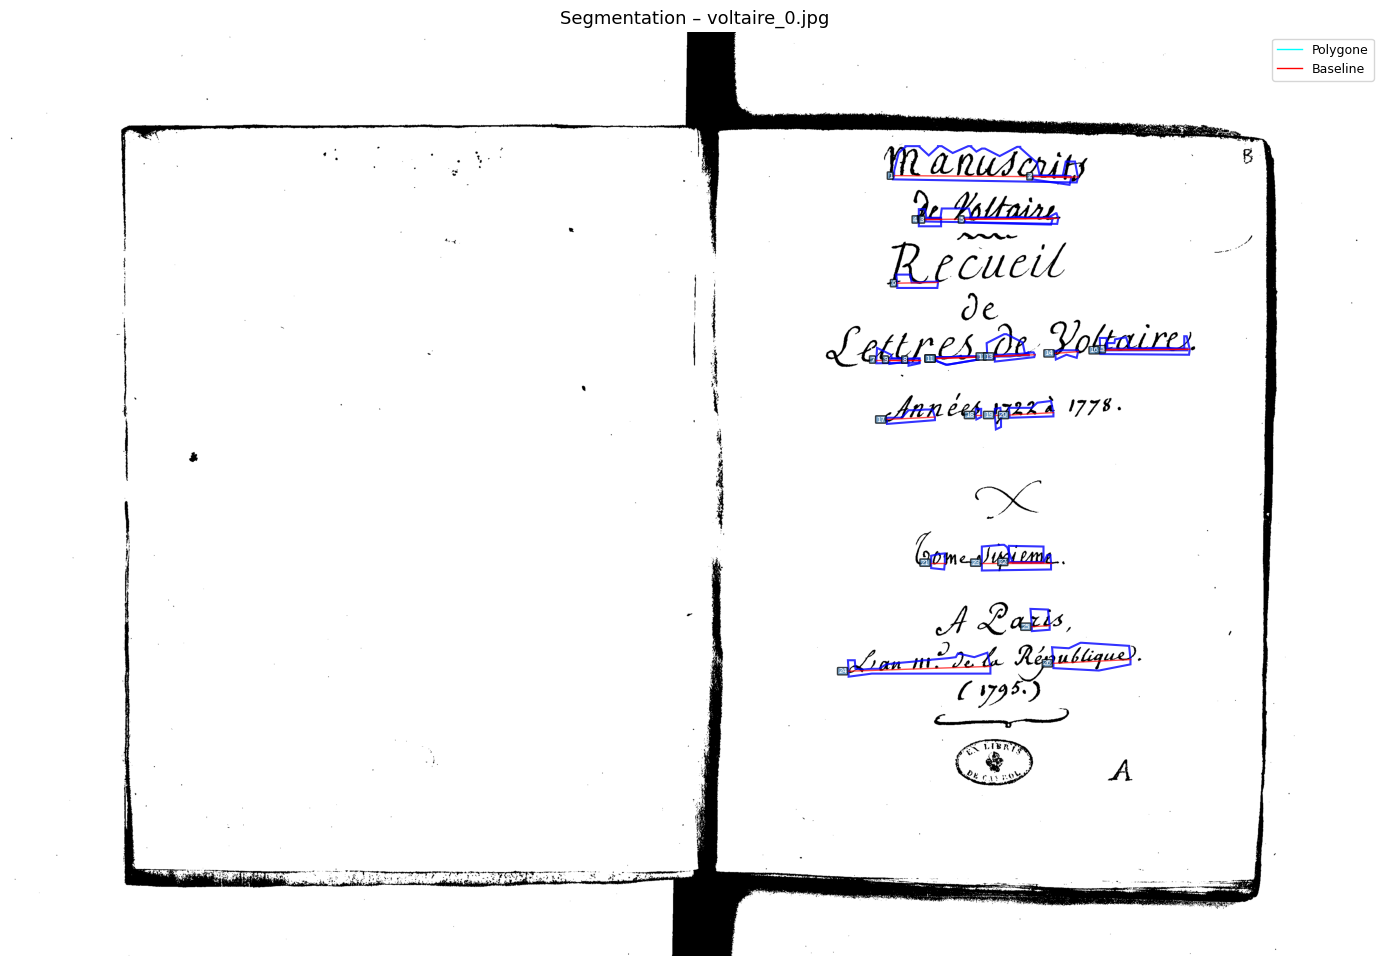

  26 lignes affichées


In [133]:
inspecter_ordre_lecture(seg)
visualiser_segmentation(image, seg, titre=f"Segmentation – {os.path.basename(IMAGE_TEST)}")

In [134]:
inspecter_segmentation(seg, n_lignes=17)


Inspection des 17 premières lignes :


17it [00:00, 21986.79it/s]

  Ligne 1: baseline 2 pts, polygone 53 pts, tags={'type': [{'type': 'DefaultLine'}]}
  Ligne 2: baseline 2 pts, polygone 11 pts, tags={'type': [{'type': 'HeadingLine'}]}
  Ligne 3: baseline 2 pts, polygone 23 pts, tags={'type': [{'type': 'HeadingLine'}]}
  Ligne 4: baseline 2 pts, polygone 10 pts, tags={'type': [{'type': 'DefaultLine'}]}
  Ligne 5: baseline 2 pts, polygone 18 pts, tags={'type': [{'type': 'DefaultLine'}]}
  Ligne 6: baseline 2 pts, polygone 12 pts, tags={'type': [{'type': 'DefaultLine'}]}
  Ligne 7: baseline 2 pts, polygone 12 pts, tags={'type': [{'type': 'DefaultLine'}]}
  Ligne 8: baseline 2 pts, polygone 8 pts, tags={'type': [{'type': 'HeadingLine'}]}
  Ligne 9: baseline 2 pts, polygone 9 pts, tags={'type': [{'type': 'HeadingLine'}]}
  Ligne 10: baseline 2 pts, polygone 15 pts, tags={'type': [{'type': 'DefaultLine'}]}
  Ligne 11: baseline 2 pts, polygone 15 pts, tags={'type': [{'type': 'HeadingLine'}]}
  Ligne 12: baseline 2 pts, polygone 19 pts, tags={'type': [{'typ

### 6. Reconnaissance HTR


In [135]:
def reconnaitre_lignes_kraken(image_pil, resultats_blla, modele_htr, pad=16):
    """
    Reconnaissance HTR robuste compatible Kraken récents.
    """
    predictions = rpred.rpred(
        network=modele_htr,
        im=image_pil,
        bounds=resultats_blla,
        pad=pad,
        bidi_reordering=True
    )
    resultats = []

    for i, pred in tqdm(
        enumerate(predictions),
        desc="HTR",
        unit="ligne"
    ):
        confidences = []

        if hasattr(pred, "cuts") and pred.cuts:
            for cut in pred.cuts:
                try:
                    # Kraken ancien format
                    if len(cut) == 2:
                        _, conf = cut
                    # Kraken récent
                    else:
                        conf = cut[-1]
                    conf = float(conf)

                    if 0.0 <= conf <= 1.0:
                        confidences.append(conf)

                except Exception:
                    continue

        confiance = (
            float(np.mean(confidences))
            if confidences
            else 0.0
        )

        baseline = None
        boundary = None

        if hasattr(pred, "line") and pred.line is not None:

            baseline = getattr(pred.line, "baseline", None)
            boundary = getattr(pred.line, "boundary", None)

        resultats.append({
            "id": f"l{i:04d}",
            "transcription": pred.prediction.strip(),
            "confiance": confiance,
            "baseline": baseline,
            "polygone": boundary,
            "cuts": pred.cuts,
        })
    return resultats

In [136]:
def visualiser_transcriptions(image_pil, resultats_htr, seuil_confiance=0.7, figsize=(16,20)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image_pil)
    ax.axis("off")
    ax.set_title("Transcriptions HTR", fontsize=13)

    for res in tqdm(resultats_htr):
        if not res["baseline"]:
            continue
        bx, by = zip(*res["baseline"])
        confiant = res["confiance"] >= seuil_confiance
        couleur = "limegreen" if confiant else "orange"
        ax.plot(bx, by, color=couleur, lw=1.5, alpha=0.6)
        ax.text(bx[0], by[0]-6, res["transcription"], fontsize=15, color="black",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6), va="bottom")

    legend_elements = [plt.Line2D([0], [0], color="limegreen", lw=2, label=f"Conf ≥ {seuil_confiance}"),
                       plt.Line2D([0], [0], color="orange", lw=2, label=f"Conf < {seuil_confiance}")]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


In [137]:
resultats_htr = reconnaitre_lignes_kraken(image, seg, modele_htr)
resultats_htr

HTR: 0ligne [00:00, ?ligne/s]/home/barachiel/.local/lib/python3.13/site-packages/kraken/rpred.py:339: UserWarning: Using legacy polygon extractor, as the model was not trained with the new method. Please retrain your model to get speed improvement.
  warnings.warn('Using legacy polygon extractor, as the model was not trained with the new method. Please retrain your model to get speed improvement.')
HTR: 26ligne [00:01, 16.01ligne/s]


[{'id': 'l0000',
  'transcription': 'R ARtACef.',
  'confiance': 0.0,
  'baseline': None,
  'polygone': None,
  'cuts': (([2581, 404], [2581, 418], [2581, 418], [2581, 404]),
   ([2686, 355], [2686, 431], [2686, 431], [2686, 355]),
   ([2701, 342], [2700, 431], [2700, 431], [2701, 342]),
   ([2778, 341], [2777, 432], [2777, 432], [2778, 341]),
   ([2834, 341], [2833, 433], [2833, 433], [2834, 341]),
   ([2912, 349], [2911, 435], [2911, 435], [2912, 349]),
   ([2961, 347], [2960, 435], [2960, 435], [2961, 347]),
   ([3058, 420], [3058, 437], [3058, 437], [3058, 420]),
   ([3093, 377], [3093, 438], [3093, 438], [3093, 377]),
   ([3118, 422], [3118, 422], [3118, 422], [3118, 422]))},
 {'id': 'l0001',
  'transcription': 'L',
  'confiance': 0.0,
  'baseline': None,
  'polygone': None,
  'cuts': (([2988, 418], [2988, 420], [2988, 420], [2988, 418]),)},
 {'id': 'l0002',
  'transcription': 'E¬',
  'confiance': 0.0,
  'baseline': None,
  'polygone': None,
  'cuts': (([3031, 540], [3031, 559], [

100%|██████████| 26/26 [00:00<00:00, 250119.05it/s]

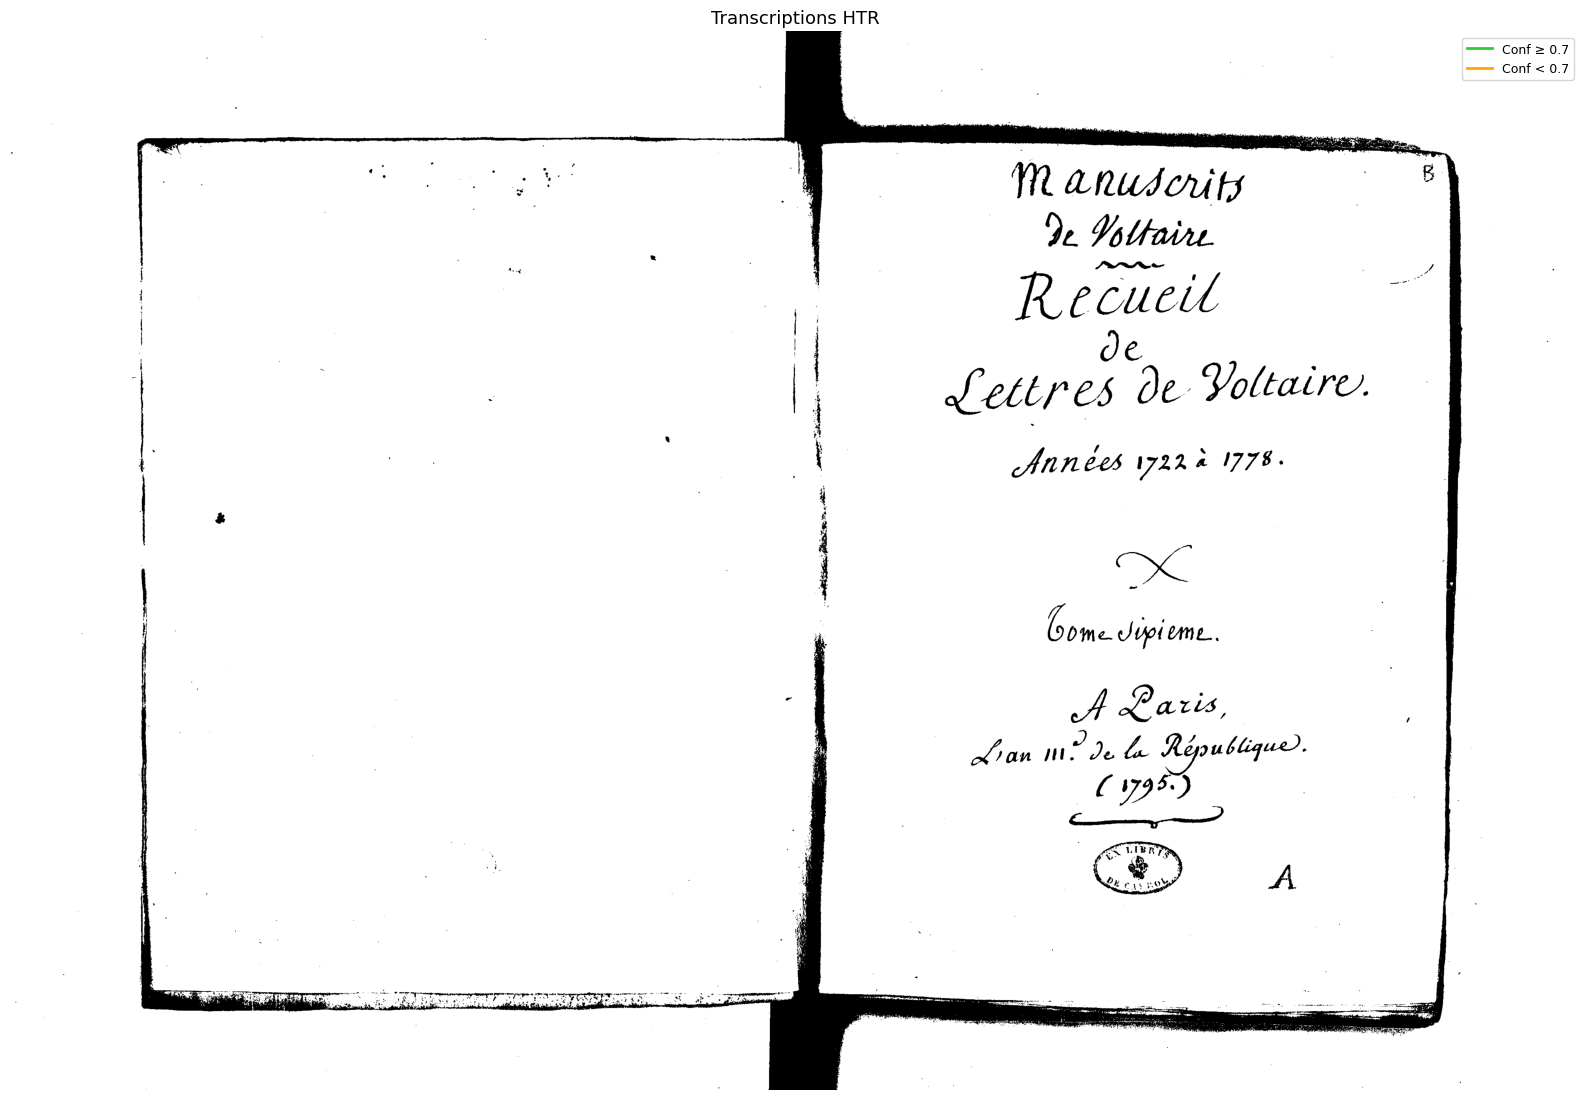

In [138]:
visualiser_transcriptions(image, resultats_htr, seuil_confiance=0.7)


### 8. Alignement et calcul du CER

In [139]:
def comparer_transcriptions(htr_lines, gt_lines, aligner_auto=False):
    """
    Compare deux listes de transcriptions (manuelle vs auto).
    
    Args:
        htr_lines : list[str] – transcriptions automatiques (ordre Kraken)
        gt_lines  : list[str] – transcriptions manuelles (ordre de lecture)
        aligner_auto : si True, aligne les deux listes par similarité globale
                       (utile si les nombres de lignes diffèrent)
    
    Returns:
        dict contenant CER global, CER par ligne, etc.
    """
    if aligner_auto:
        # Alignement simple par distance d'édition globale (à utiliser avec prudence)
        from itertools import permutations
        # Ce n'est pas robuste ; il vaut mieux vérifier manuellement l'ordre
        print("Alignement automatique non implémenté – vérifiez que les ordres correspondent.")
    
    n = min(len(htr_lines), len(gt_lines))
    if len(htr_lines) != len(gt_lines):
        print(f"⚠ Nombre de lignes différent : HTR={len(htr_lines)}, GT={len(gt_lines)}")
        print("  Seules les {n} premières lignes seront comparées.")
    
    cer_lignes = []
    for i in range(n):
        cer_ligne = cer(gt_lines[i], htr_lines[i])
        cer_lignes.append(cer_ligne)
    
    # Concaténer tout le texte pour le CER global
    gt_global = "\n".join(gt_lines[:n])
    htr_global = "\n".join(htr_lines[:n])
    
    cer_global = cer(gt_global, htr_global)
    wer_global = wer(gt_global, htr_global)
    
    return {
        "cer_global": cer_global,
        "wer_global": wer_global,
        "cer_par_ligne": cer_lignes,
        "cer_moyen": np.mean(cer_lignes),
        "n_lignes_comparees": n,
        "lignes_htr": htr_lines[:n],
        "lignes_gt": gt_lines[:n]
    }

In [140]:
# Chargement du fichier ground truth
gt_path = "../data/test/transcription/voltaire_0.txt"
with open(gt_path, "r", encoding="utf-8") as f:
    gt_lines = [l.rstrip("\n") for l in f.readlines()]

# Extraire les transcriptions automatiques dans l'ordre de Kraken
htr_lines = [r["transcription"] for r in resultats_htr]

# Comparaison
comparaison = comparer_transcriptions(htr_lines, gt_lines, aligner_auto=False)
comparaison

⚠ Nombre de lignes différent : HTR=26, GT=14
  Seules les {n} premières lignes seront comparées.


{'cer_global': 0.8930817610062893,
 'wer_global': 1.0,
 'cer_par_ligne': [1.0,
  1.0,
  1.0,
  1.0,
  0.9473684210526315,
  1.0,
  1,
  1.0,
  1,
  1.0,
  0.9629629629629629,
  1.0,
  1.0,
  1.0],
 'cer_moyen': np.float64(0.9935950988582568),
 'n_lignes_comparees': 14,
 'lignes_htr': ['R ARtACef.',
  'L',
  'E¬',
  'P',
  'L.',
  '',
  'U',
  '1',
  'A',
  '',
  'L',
  'C6',
  'A.',
  'L'],
 'lignes_gt': ['Manuscrits B',
  'de Voltaire',
  'Receuil ',
  'de ',
  'Lettres de Voltaire',
  'Années 1722 à 1778',
  '',
  'Tome sixieme',
  '',
  'A Paris,',
  "L'an 111.e de la République",
  '(1795.)',
  'Ex Libris ',
  'De Cayrol A']}